# Final Project

Student name and id: Mohammad Sajjad Zanganeh - 402222077  
Course: Image Processing - Spring 1405  
Professor: Dr. Mahmoodi


# 0. Environment Setup


## 0.1 Mount Drive and Create Project Folders


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_DIR = "/content/drive/MyDrive/SBU-DIP-Final-Project"

if not os.path.exists(PROJECT_DIR):
    !git clone https://github.com/SrgtSajjad/SBU-DIP-Final-Project.git "{PROJECT_DIR}"
else:
    print("Repository already exists.")

%cd "{PROJECT_DIR}"

folders = [
    "models",
    "noisy_inputs",
    "original_inputs",
    "phase_1_results",
    "phase_2_results",
    "phase_3_results",
    "utils",
    "models_architecture"
]

for folder in folders:
    os.makedirs(os.path.join(PROJECT_DIR, folder), exist_ok=True)

print("Project folders are ready!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Repository already exists.
/content/drive/MyDrive/SBU-DIP-Final-Project
Project folders are ready!


## 0.2 Install Requirements


In [ ]:
!pip install -r requirements.txt

## 0.3 Import Libraries


In [ ]:
# Standard library
import random

# Numerical computing
import numpy as np

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

import tensorflow as tf

# Image processing
import cv2
from PIL import Image

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Evaluation metrics
from sklearn.metrics import f1_score, confusion_matrix

## 0.4 Verify GPU


In [ ]:
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

print("\nTensorFlow:", tf.__version__)
print(tf.config.list_physical_devices("GPU"))

Torch: 2.11.0+cu128
CUDA available: True

TensorFlow: 2.20.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# 1. Deep Denoising


## 1.1 Denoising Function


In [ ]:
def denoising(image_path, dest_path, model_path):
    # 1. Load the downloaded model
    # Point this to your .h5 file or the unzipped SavedModel directory
    model = tf.keras.models.load_model(model_path, compile=False)

    # 2. Load and Preprocess the Noisy Image
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # CRITICAL: Most Kaggle models expect a fixed input size (e.g., 256x256).
    # You might need to check the Kaggle page for the exact dimensions, but 256 is standard.
    image = cv2.resize(image, (256, 256))

    # Normalize the image (Neural networks usually expect values between 0.0 and 1.0)
    input_tensor = image.astype(np.float32) / 255.0

    # Add the batch dimension (shape becomes 1, 256, 256, 3)
    input_tensor = np.expand_dims(input_tensor, axis=0)

    # 3. Pass through the model
    denoised_tensor = model.predict(input_tensor)

    # 4. Postprocess and Save
    # Remove batch dimension and scale back to 0-255
    denoised_image = denoised_tensor[0] * 255.0
    denoised_image = np.clip(denoised_image, 0, 255).astype(np.uint8)

    # Convert back to BGR for OpenCV saving
    denoised_image = cv2.cvtColor(denoised_image, cv2.COLOR_RGB2BGR)
    cv2.imwrite(dest_path, denoised_image)
    print("Denoised image saved successfully!")

## 1.2 Run Denoising


In [ ]:
DENOISING_MODEL = os.path.join(PROJECT_DIR, "models", "denoising_model.h5")
NOISY_IMAGE = os.path.join(PROJECT_DIR, "noisy_inputs", "corrupted_bird.jpeg")
DENOISED_IMAGE = os.path.join(PROJECT_DIR, "phase_1_results", "denoised_bird.jpeg")

denoising(image_path=NOISY_IMAGE, dest_path=DENOISED_IMAGE, model_path=DENOISING_MODEL)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step
Denoised image saved successfully!


## 1.3 Compare Denoised Image


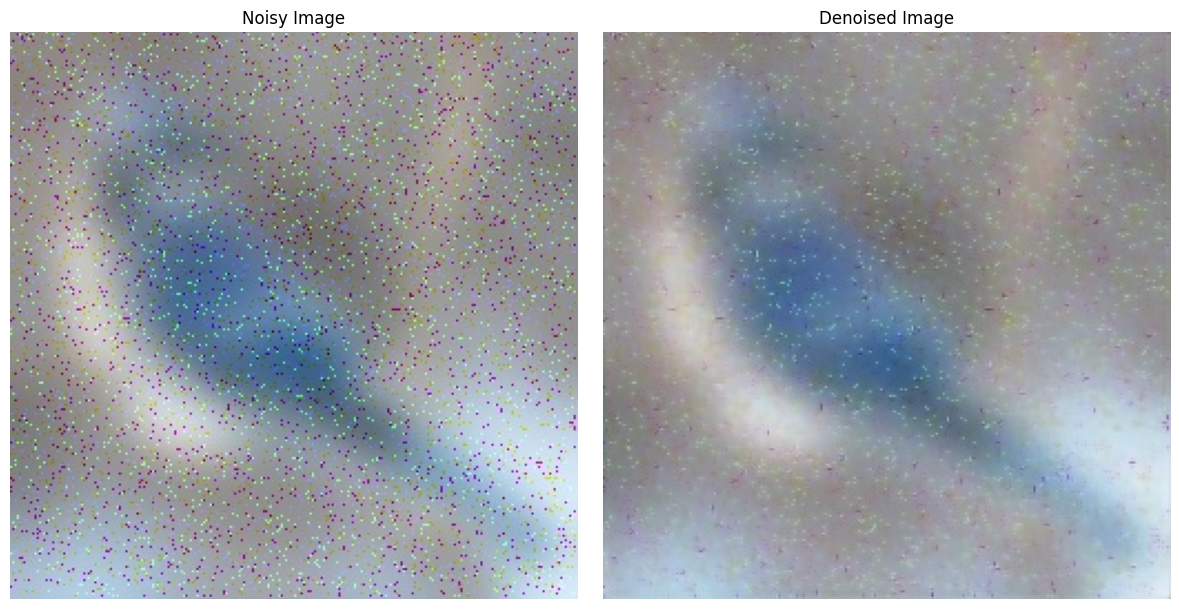

In [ ]:
noisy = cv2.imread("noisy_inputs/corrupted_bird.jpeg")
noisy = cv2.cvtColor(noisy, cv2.COLOR_BGR2RGB)

denoised = cv2.imread("phase_1_results/denoised_bird.jpeg")
denoised = cv2.cvtColor(denoised, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(noisy)
plt.title("Noisy Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(denoised)
plt.title("Denoised Image")
plt.axis("off")

plt.tight_layout()
plt.show()

# 2. Deep Deblurring


## 2.1 Deblurring Function


In [ ]:
from models_architecture.cnn import CNN
from models_architecture.resnet import ResNet
from models_architecture.unet import UNet


def apply_deblur_model(model_path, input_path, destination_path, model_name):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # A. Initialize the empty model architecture
    if model_name == "cnn":
        model = CNN()
    elif model_name == "resnet":
        model = ResNet()
    elif model_name == "unet":
        model = UNet()
    elif model_name == "DiffCNN":
        model = DiffCNN(in_channels=3, cond_channels=3, time_emb_dim=256)
    elif model_name == "DiffResNet":
        model = DiffResNet(
            in_channels=3, cond_channels=3, out_channels=3, time_emb_dim=256
        )
    elif model_name == "DiffUNet":
        model = DiffUNet(
            in_channels=3, cond_channels=3, out_channels=3, time_emb_dim=256
        )

    # B. Load the checkpoint
    checkpoint = torch.load(model_path, map_location=device)

    # C. Load the standard weights first
    model.load_state_dict(checkpoint["model_state"])

    # D. Set to evaluation mode and move to device
    model.eval()
    model.to(device)

    # E. Preprocessing pipeline
    preprocess = transforms.Compose(
        [transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]
    )

    try:
        img = Image.open(input_path).convert("RGB")
        cond_tensor = preprocess(img).unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(cond_tensor)
        output_tensor = output.squeeze(0).cpu()

        # F. Postprocessing
        output_tensor = (output_tensor + 1) / 2.0
        output_tensor = output_tensor.clamp(0, 1)

        to_pil = transforms.ToPILImage()
        deblurred_img = to_pil(output_tensor)

        deblurred_img.save(destination_path)
        print(f"Success! Phase 2 deblurred image saved to: {destination_path}")

    except Exception as e:
        print(f"An error occurred during processing: {e}")

## 2.2 Run Deblurring


In [ ]:
INPUT_IMAGE = os.path.join(PROJECT_DIR, "phase_1_results", "denoised_bird.jpeg")

OUTPUT_DIR = os.path.join(PROJECT_DIR, "phase_2_results")

MODELS_DIR = os.path.join(PROJECT_DIR, "models")

models = {"cnn": "CNN.pth", "resnet": "ResNet.pth", "unet": "UNet.pth"}

for model_name, weight_file in models.items():
    print(f"Running {model_name}...")

    apply_deblur_model(
        model_path=os.path.join(MODELS_DIR, weight_file),
        input_path=INPUT_IMAGE,
        destination_path=os.path.join(OUTPUT_DIR, f"{model_name}_bird.jpeg"),
        model_name=model_name,
    )

print("Finished!")

Running cnn...
Success! Phase 2 deblurred image saved to: /content/drive/MyDrive/SBU-DIP-Final-Project/phase_2_results/cnn_bird.jpeg
Running resnet...
Success! Phase 2 deblurred image saved to: /content/drive/MyDrive/SBU-DIP-Final-Project/phase_2_results/resnet_bird.jpeg
Running unet...
Success! Phase 2 deblurred image saved to: /content/drive/MyDrive/SBU-DIP-Final-Project/phase_2_results/unet_bird.jpeg
Finished!


## 2.3 Compare Results


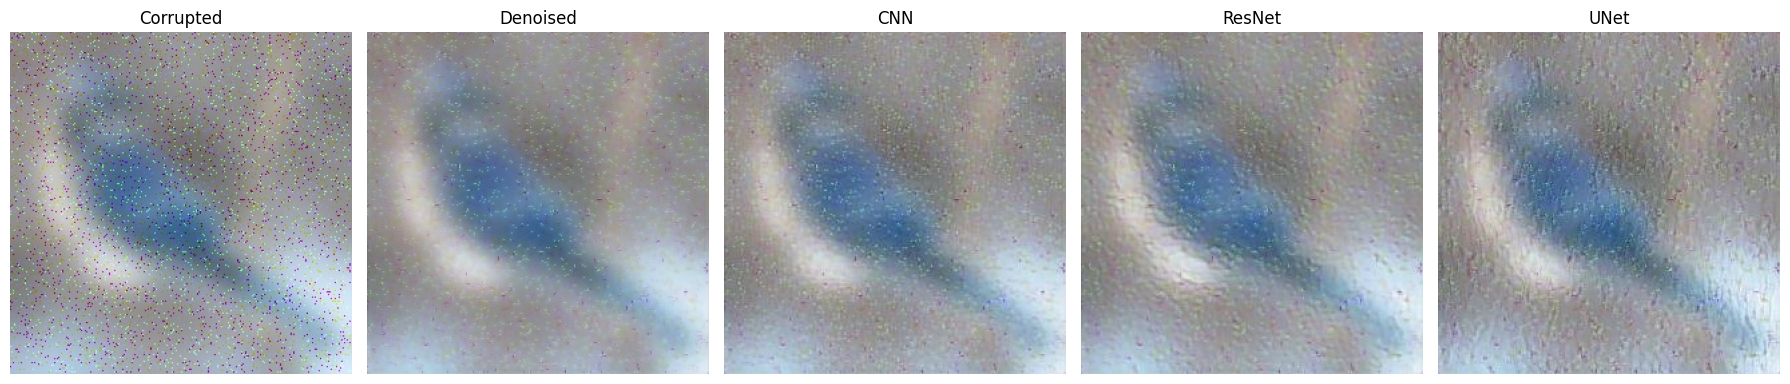

In [ ]:
images = {
    "Corrupted": os.path.join(PROJECT_DIR, "noisy_inputs", "corrupted_bird.jpeg"),
    "Denoised": os.path.join(PROJECT_DIR, "phase_1_results", "denoised_bird.jpeg"),
    "CNN": os.path.join(PROJECT_DIR, "phase_2_results", "cnn_bird.jpeg"),
    "ResNet": os.path.join(PROJECT_DIR, "phase_2_results", "resnet_bird.jpeg"),
    "UNet": os.path.join(PROJECT_DIR, "phase_2_results", "unet_bird.jpeg"),
}

plt.figure(figsize=(18, 10))

for i, (title, path) in enumerate(images.items(), start=1):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, 5, i)
    plt.imshow(img)
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()

# 3. Classification


## 3.1 Classifier Function


In [ ]:
from models_architecture.preact_resnet import PreActResNet18


def classifier(model_path, image_path, ground_truth):
    print("classifer")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    classes = (
        "plane",
        "car",
        "bird",
        "cat",
        "deer",
        "dog",
        "frog",
        "horse",
        "ship",
        "truck",
    )

    # 1. Load the fully compiled model (No architecture class needed!)
    model = torch.jit.load(model_path, map_location=device)
    # model = torch.load(model_path, map_location=device, weights_only=False)
    model.eval()

    # 2. Prepare the image (omitting Resize to support any size)
    transform = transforms.Compose(
        [
            transforms.Resize((32, 32)),
            transforms.ToTensor(),
            transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
        ]
    )

    try:
        img = Image.open(image_path).convert("RGB")
        print(f"Original image size: {img.size}")
    except Exception as e:
        print(f"Error loading image: {e}")
        return

    # Add batch dimension and move to device
    img_tensor = transform(img).unsqueeze(0).to(device)

    # 3. Run Inference
    with torch.no_grad():
        outputs = model(img_tensor)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        confidence, predicted = torch.max(probabilities, 1)

    print(f"--- Inference Results ---")
    print(f"Predicted Class : {classes[predicted.item()]}")
    print(f"ground truth is: {ground_truth}")
    print(f"Confidence      : {confidence.item() * 100:.2f}%")

## 3.2 Core Training & Compilation Pipeline


In [ ]:
def set_seed(seed=42):
    """Fix all random seeds to make training deterministic."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # if multi-GPU

    # Make cuDNN deterministic (slower, but reproducible)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # Optional: force all torch ops to be deterministic
    # (only works if your model contains no non-deterministic ops)
    try:
        torch.use_deterministic_algorithms(True)
    except AttributeError:
        pass  # older PyTorch – already covered by cuDNN flags


def seed_worker(worker_id):
    """DataLoader worker seed init – used to guarantee same augmentation sequence."""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


# ---------- Main Training Function ----------
def train_model(model_architect):
    # 1. Fix EVERYTHING before creating any randomness
    set_seed(42)  # You can change the seed to any integer

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Training on: {device}")

    # 2. Transforms (unchanged)
    transform_train = transforms.Compose(
        [
            transforms.RandomCrop(32, padding=4),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
        ]
    )

    transform_test = transforms.Compose(
        [
            transforms.ToTensor(),
            transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
        ]
    )

    data_dir = os.path.join(PROJECT_DIR, "data")
    os.makedirs(data_dir, exist_ok=True)

    trainset = torchvision.datasets.CIFAR10(
        root=data_dir, train=True, download=True, transform=transform_train
    )
    testset = torchvision.datasets.CIFAR10(
        root=data_dir, train=False, download=True, transform=transform_test
    )

    # 3. DataLoaders – worker_init_fn ensures deterministic data loading
    trainloader = torch.utils.data.DataLoader(
        trainset,
        batch_size=128,
        shuffle=True,
        num_workers=2,
        pin_memory=True,
        worker_init_fn=seed_worker,
    )
    testloader = torch.utils.data.DataLoader(
        testset,
        batch_size=100,
        shuffle=False,
        num_workers=2,
        pin_memory=True,
        worker_init_fn=seed_worker,
    )

    # 4. Model, loss, optimizer (initialized with fixed seed)
    model = model_architect(num_classes=10).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)

    epochs = 50
    history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_f1": []}

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        avg_train_loss = running_loss / len(trainloader)

        # Validation
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        all_preds = []
        all_targets = []

        with torch.no_grad():
            for inputs, labels in testloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

                all_preds.extend(predicted.cpu().numpy())
                all_targets.extend(labels.cpu().numpy())

        avg_val_loss = val_loss / len(testloader)
        val_acc = 100.0 * correct / total
        val_f1 = f1_score(all_targets, all_preds, average="macro")

        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(avg_val_loss)
        history["val_acc"].append(val_acc)
        history["val_f1"].append(val_f1)

        print(
            f"Epoch [{epoch+1}/{epochs}] | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Val Loss: {avg_val_loss:.4f} | "
            f"Val Acc: {val_acc:.2f}% | "
            f"Val F1: {val_f1:.4f}"
        )

    # ---------- Save Standalone TorchScript Model ----------
    model.eval()
    dummy_input = torch.randn(1, 3, 32, 32).to(device)

    # Tracing the model is deterministic (weights are fixed)
    traced_model = torch.jit.trace(model, dummy_input)
    compiled_model_path = os.path.join(
        PROJECT_DIR, "models", "preact_resnet18_standalone.pt"
    )
    traced_model.save(compiled_model_path)
    print(f"Standalone TorchScript model saved to {compiled_model_path}")

    # ---------- Plot & Save Training Metrics ----------
    epochs_range = range(1, epochs + 1)
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.plot(epochs_range, history["train_loss"], label="Train Loss")
    plt.plot(epochs_range, history["val_loss"], label="Val Loss")
    plt.title("Loss")
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(epochs_range, history["val_acc"], label="Val Accuracy", color="green")
    plt.title("Accuracy (%)")
    plt.legend()

    plt.subplot(1, 3, 3)
    plt.plot(epochs_range, history["val_f1"], label="Val F1 (Macro)", color="purple")
    plt.title("F1 Score")
    plt.legend()

    plt.tight_layout()
    plt.savefig(
        os.path.join(
            PROJECT_DIR, "phase_2_results", "PreActResNet_training_metrics.png"
        )
    )
    print("Chart saved to training_metrics.png")
    plt.close()

## 3.3 Quantitative Evaluation Utility


In [ ]:
def check_image_similarity(original_path, test_path):
    # 1. Load the images
    img_original = cv2.resize(cv2.imread(original_path), (256, 256))
    img_test = cv2.imread(test_path)
    print(img_original.shape)
    # Safety check: Ensure both images loaded successfully
    if img_original is None:
        raise ValueError(f"Could not load original image at: {original_path}")
    if img_test is None:
        raise ValueError(f"Could not load test image at: {test_path}")

    # Safety check: PSNR requires exact same dimensions
    if img_original.shape != img_test.shape:
        raise ValueError(
            f"Dimension mismatch! Original is {img_original.shape}, but Test is {img_test.shape}."
        )

    # 2. Calculate PSNR using OpenCV's built-in method
    psnr_value = cv2.PSNR(img_original, img_test)

    return psnr_value

## 3.4 Classification Evaluation Utility


In [ ]:
def plot_cifar_confusion_matrix(model_path, data_dir="./data"):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    classes = (
        "plane",
        "car",
        "bird",
        "cat",
        "deer",
        "dog",
        "frog",
        "horse",
        "ship",
        "truck",
    )

    print(f"Loading TorchScript model from {model_path}...")
    # Load the standalone model
    model = torch.jit.load(model_path, map_location=device)
    model.eval()

    print("Loading test dataset...")
    transform_test = transforms.Compose(
        [
            transforms.ToTensor(),
            transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
        ]
    )

    # Note: Setting download=True as a fallback just in case the Colab runtime restarted
    testset = torchvision.datasets.CIFAR10(
        root=data_dir, train=False, download=True, transform=transform_test
    )
    testloader = torch.utils.data.DataLoader(
        testset, batch_size=512, shuffle=False, num_workers=2
    )

    all_preds = []
    all_targets = []

    print("Running inference on test set (10,000 images)...")
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)

            # Store predictions and true labels
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(labels.cpu().numpy())

    print("Generating Confusion Matrix...")
    cm = confusion_matrix(all_targets, all_preds)

    # Plotting the heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=classes,
        yticklabels=classes,
        cbar_kws={"label": "Number of Images"},
    )

    plt.title("PreActResNet18 CIFAR-10 Confusion Matrix", fontsize=14)
    plt.ylabel("True Class", fontsize=12)
    plt.xlabel("Predicted Class", fontsize=12)

    # Rotate x labels for better readability
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()

    # Show and save the plot
    save_path = os.path.join(
        PROJECT_DIR, "phase_3_results", "cifar10_confusion_matrix.png"
    )
    plt.savefig(save_path, dpi=300)
    plt.show()
    print(f"Saved matrix to {save_path}")

## 3.5 Train the Classifier


In [ ]:
train_model(model_architect=PreActResNet18)

Training on: cuda


100%|██████████| 170M/170M [45:11<00:00, 62.9kB/s]


Epoch [1/50] | Train Loss: 1.9698 | Val Loss: 1.4965 | Val Acc: 43.17% | Val F1: 0.4236
Epoch [2/50] | Train Loss: 1.3318 | Val Loss: 1.2375 | Val Acc: 55.61% | Val F1: 0.5572
Epoch [3/50] | Train Loss: 1.0524 | Val Loss: 1.0834 | Val Acc: 62.65% | Val F1: 0.6260
Epoch [4/50] | Train Loss: 0.9114 | Val Loss: 0.8295 | Val Acc: 71.41% | Val F1: 0.7161
Epoch [5/50] | Train Loss: 0.7866 | Val Loss: 1.1118 | Val Acc: 65.11% | Val F1: 0.6402
Epoch [6/50] | Train Loss: 0.6758 | Val Loss: 0.9617 | Val Acc: 70.64% | Val F1: 0.7037
Epoch [7/50] | Train Loss: 0.6190 | Val Loss: 0.8529 | Val Acc: 72.73% | Val F1: 0.7305
Epoch [8/50] | Train Loss: 0.5630 | Val Loss: 0.6754 | Val Acc: 77.37% | Val F1: 0.7799
Epoch [9/50] | Train Loss: 0.5281 | Val Loss: 0.6214 | Val Acc: 79.86% | Val F1: 0.7990
Epoch [10/50] | Train Loss: 0.4927 | Val Loss: 0.5503 | Val Acc: 82.02% | Val F1: 0.8187
Epoch [11/50] | Train Loss: 0.4650 | Val Loss: 0.6592 | Val Acc: 78.69% | Val F1: 0.7854
Epoch [12/50] | Train Loss: 0.

## 3.6 Generate Confusion Matrix


Loading TorchScript model from /content/drive/MyDrive/SBU-DIP-Final-Project/models/preact_resnet18_standalone.pt...
Loading test dataset...
Running inference on test set (10,000 images)...
Generating Confusion Matrix...


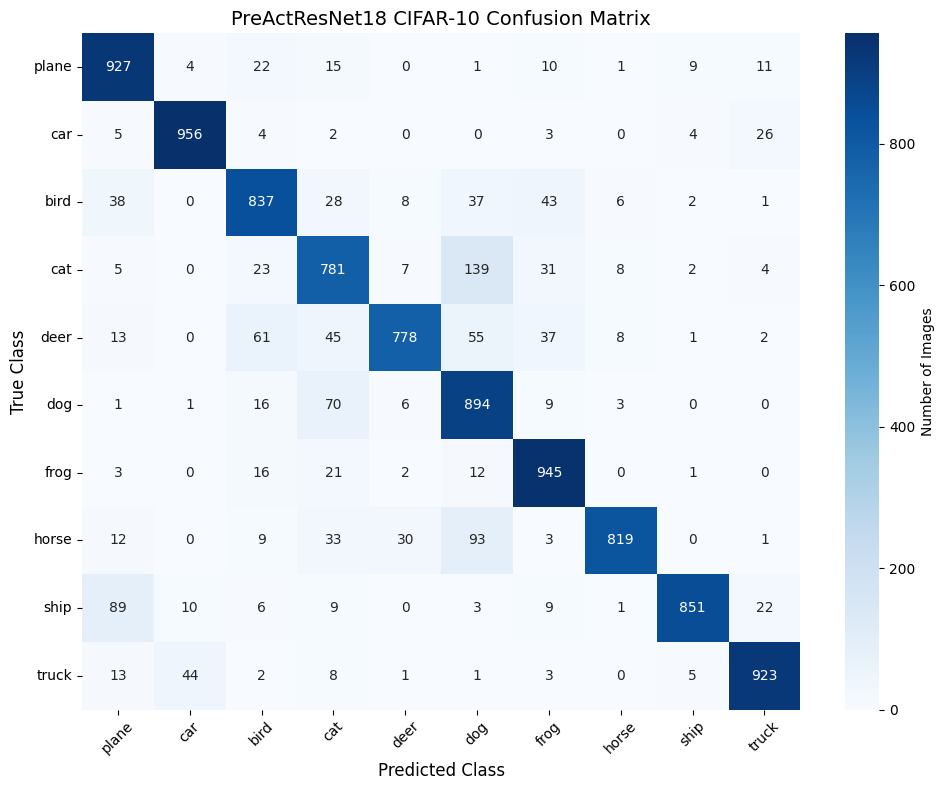

Saved matrix to /content/drive/MyDrive/SBU-DIP-Final-Project/phase_3_results/cifar10_confusion_matrix.png


In [ ]:
plot_cifar_confusion_matrix(
    model_path=os.path.join(PROJECT_DIR, "models", "preact_resnet18_standalone.pt"),
    data_dir=os.path.join(PROJECT_DIR, "data"),
)

## 3.7 Classify Restored Image


In [ ]:
images = {
    "CNN": "cnn_bird.jpeg",
    "ResNet": "resnet_bird.jpeg",
    "UNet": "unet_bird.jpeg",
}

for name, image in images.items():
    print(f"=== {name} ===")

    classifier(
        model_path=os.path.join(PROJECT_DIR, "models", "preact_resnet18_standalone.pt"),
        image_path=os.path.join(PROJECT_DIR, "phase_2_results", image),
        ground_truth="bird",
    )
    print()

=== CNN ===
classifer
Original image size: (256, 256)
--- Inference Results ---
Predicted Class : plane
ground truth is: bird
Confidence      : 46.03%

=== ResNet ===
classifer
Original image size: (256, 256)
--- Inference Results ---
Predicted Class : plane
ground truth is: bird
Confidence      : 49.56%

=== UNet ===
classifer
Original image size: (256, 256)
--- Inference Results ---
Predicted Class : plane
ground truth is: bird
Confidence      : 49.38%

